<a href="https://colab.research.google.com/github/smontana009/ML_GC/blob/Prueba-31-03-25/Prueba31_03_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este dataset proviene de una empresa de ventas que realizó campañas de marketing. Contiene información demográfica, hábitos de compra y respuesta de los clientes a campañas promocionales.

# Variables destacadas:
# - Ingresos
# - Edad
# - Cantidad gastada en productos (vino, frutas, carne, etc.)
# - Número de hijos
# - Respuesta a campañas

# Desafío:
# Analizar el comportamiento de diferentes perfiles de clientes y buscar patrones de consumo asociados a variables demográficas y a la respuesta a las campañas de marketing.


In [15]:
from IPython import get_ipython
from IPython.display import display
# %%
# importa las librerías a nuestro entorno de trabajo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
#cargar dataset
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
    name=fn
# Use the 'sep' argument to specify the tab delimiter
marketing_campaign = pd.read_csv(name, sep="\t") # Changed to sep='\t'

Matriz de correlacion de perfil de clintes

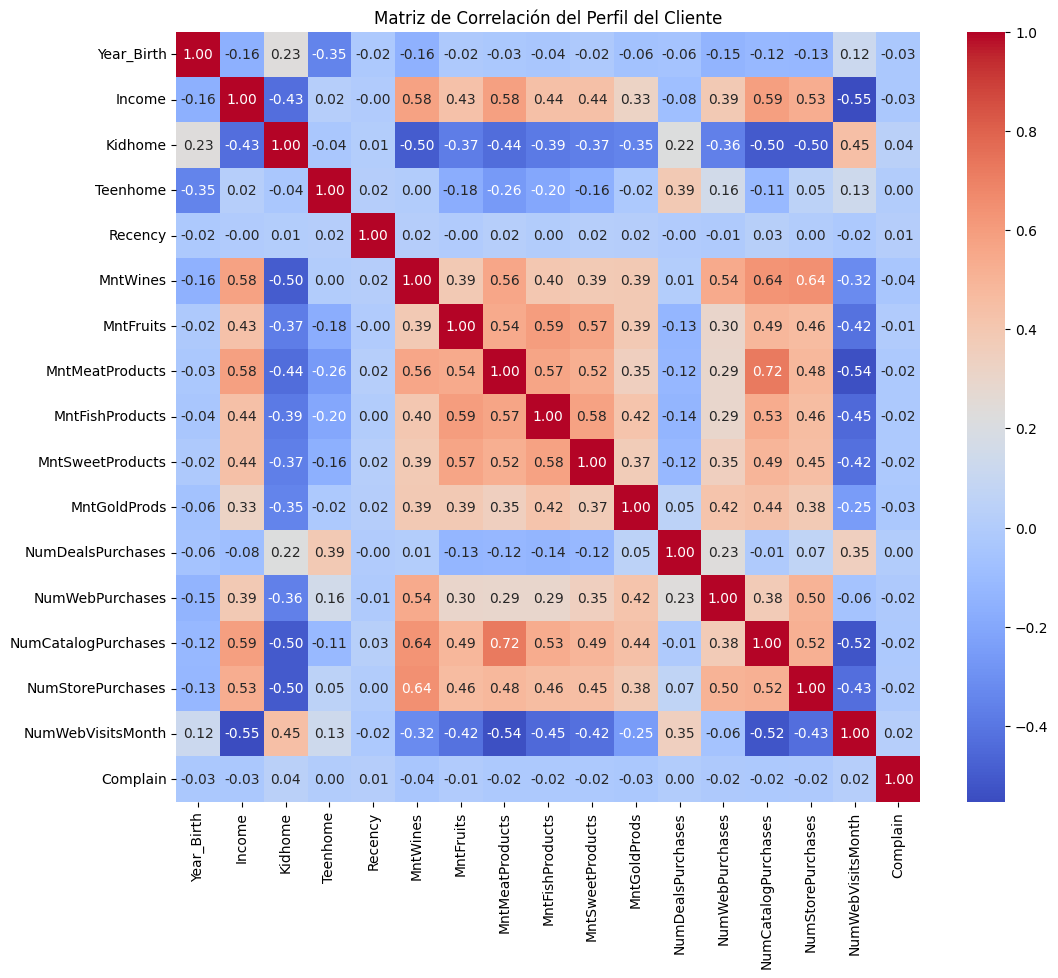

In [45]:
# Matriz de correlación considerando solo variables numéricas relacionadas con el perfil del cliente
# Seleccionar columnas relevantes para el perfil del cliente (ajusta según tus datos)
customer_profile_cols = ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain']

correlation_matrix = marketing_campaign[customer_profile_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación del Perfil del Cliente')
plt.show()

AQUI SE DISTRIBUYEN LOS PERFILES DE CLIENTES SEGUN SU NIVEL DE EDUCACION Y ESTADO MARITAL



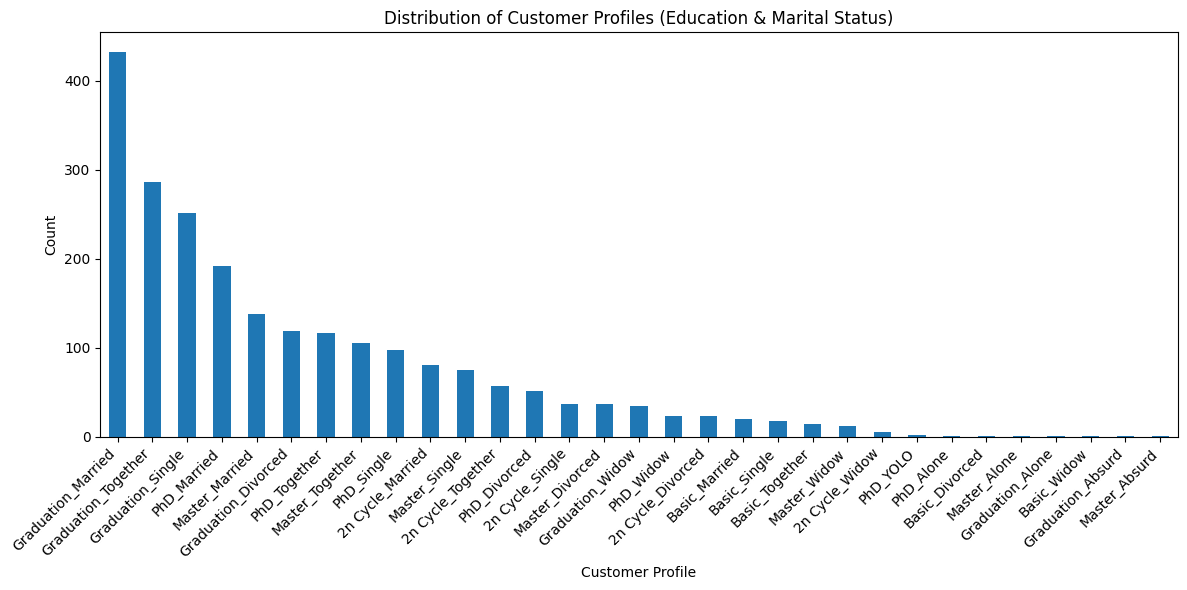

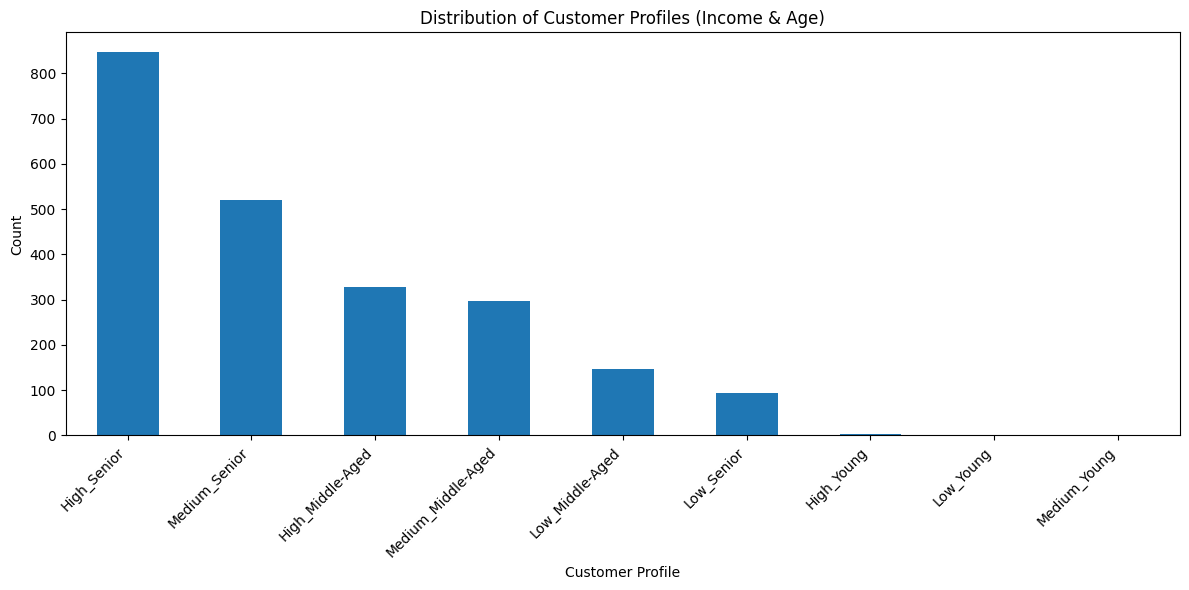

In [46]:
# Create a combined profile column
marketing_campaign['Customer_Profile'] = marketing_campaign['Education'] + '_' + marketing_campaign['Marital_Status']

# Plot the distribution of customer profiles
plt.figure(figsize=(12, 6))
marketing_campaign['Customer_Profile'].value_counts().plot(kind='bar')
plt.title('Distribution of Customer Profiles (Education & Marital Status)')
plt.xlabel('Customer Profile')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


# More advanced profiling (example using Income and Age)
# This is a basic example.  You can refine it by adding more segments/criteria

def categorize_income(income):
  if income <= 25000:
    return 'Low'
  elif income <= 50000:
    return 'Medium'
  else:
    return 'High'

def categorize_age(age):
  if age <= 30:
    return 'Young'
  elif age <= 50:
    return 'Middle-Aged'
  else:
    return 'Senior'

marketing_campaign['Income_Category'] = marketing_campaign['Income'].apply(categorize_income)
marketing_campaign['Age_Category'] = marketing_campaign['Age'].apply(categorize_age)

marketing_campaign['Combined_Category'] = marketing_campaign['Income_Category'] + '_' + marketing_campaign['Age_Category']
plt.figure(figsize=(12, 6))
marketing_campaign['Combined_Category'].value_counts().plot(kind='bar')
plt.title('Distribution of Customer Profiles (Income & Age)')
plt.xlabel('Customer Profile')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Patrones de consumo en cuanto consumen en promedio los tipos de clientes los siguientes productos : vino, frutas y carne

                     Avg_Wine_Spending  Avg_Fruit_Spending  Avg_Meat_Spending
Customer_Profile                                                             
2n Cycle_Divorced           351.173913           25.565217         150.695652
2n Cycle_Married            154.777778           27.469136         122.654321
2n Cycle_Single             209.945946           31.135135         177.405405
2n Cycle_Together           188.421053           28.684211         136.649123
2n Cycle_Widow              221.800000           55.600000         184.200000
Basic_Divorced                0.000000            1.000000           3.000000
Basic_Married                15.200000           15.450000          17.000000
Basic_Single                  3.111111            9.166667           7.611111
Basic_Together                2.000000            8.714286           8.142857
Basic_Widow                   3.000000            3.000000          24.000000
Graduation_Absurd           471.000000          102.000000      

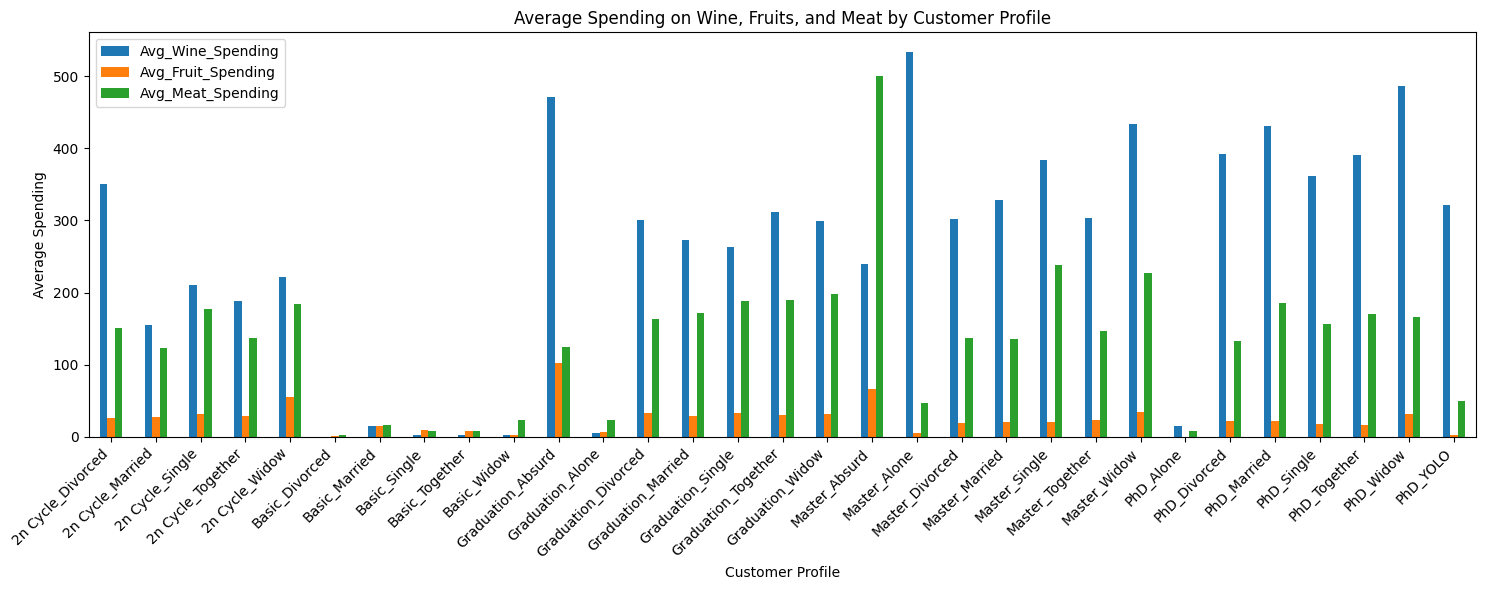

                    Avg_Wine_Spending  Avg_Fruit_Spending  Avg_Meat_Spending
Combined_Category                                                           
High_Middle-Aged           518.492401           52.851064         337.808511
High_Senior                515.464623           40.303066         265.387972
High_Young                 471.000000           31.666667         531.000000
Low_Middle-Aged             10.383562            7.082192          26.856164
Low_Senior                  12.436170            4.500000          13.978723
Low_Young                    1.500000            9.000000           8.000000
Medium_Middle-Aged          63.054054            7.209459          38.371622
Medium_Senior               96.817308            7.007692          37.607692
Medium_Young                 4.000000            2.000000          11.000000


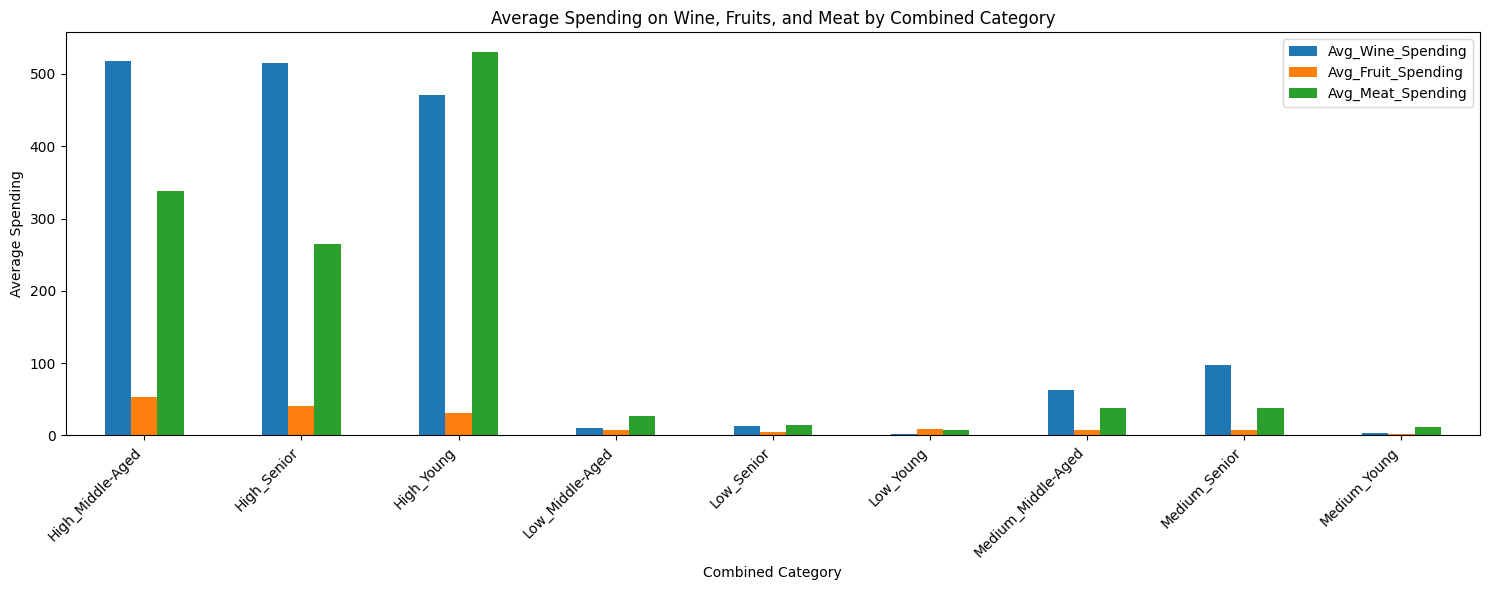

In [38]:


# Group data by customer profile and calculate the average spending on wine, fruit, and meat
customer_spending = marketing_campaign.groupby('Customer_Profile').agg(
    {'MntWines': 'mean', 'MntFruits': 'mean', 'MntMeatProducts': 'mean'}
)

# Rename columns for clarity
customer_spending = customer_spending.rename(
    columns={
        'MntWines': 'Avg_Wine_Spending',
        'MntFruits': 'Avg_Fruit_Spending',
        'MntMeatProducts': 'Avg_Meat_Spending'
    }
)

# Display the results
print(customer_spending)

# Plotting average spending for each product category by customer profile
customer_spending.plot(kind='bar', figsize=(15, 6))
plt.title('Average Spending on Wine, Fruits, and Meat by Customer Profile')
plt.xlabel('Customer Profile')
plt.ylabel('Average Spending')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Similar analysis for the combined category
combined_category_spending = marketing_campaign.groupby('Combined_Category').agg(
    {'MntWines': 'mean', 'MntFruits': 'mean', 'MntMeatProducts': 'mean'}
)

combined_category_spending = combined_category_spending.rename(
    columns={
        'MntWines': 'Avg_Wine_Spending',
        'MntFruits': 'Avg_Fruit_Spending',
        'MntMeatProducts': 'Avg_Meat_Spending'
    }
)

print(combined_category_spending)

combined_category_spending.plot(kind='bar', figsize=(15, 6))
plt.title('Average Spending on Wine, Fruits, and Meat by Combined Category')
plt.xlabel('Combined Category')
plt.ylabel('Average Spending')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


SE ANALIZARON LOS LOS PROMEDIOS DE CONSUMOS DE LOS PRODUCTOS PARA LOS DISTINTOS TIPOS DE CLIENTES SEGUN SU NIVEL DE EDUCACION Y SU GRUPO ETARIO.